# Challenger 5/5: Explainable Boosting Machine — Dementia Screening Challenger

**Benchmark protocol — identical to `modelx.ipynb` (logistic regression incumbent).**

| Element | Locked value |
|---|---|
| Data | `outputs/clean_data.csv` (11,924 rows, modelx §4 cleaning) |
| Split | 80/20 stratified, `random_state=42` — asserted to reproduce modelx exactly |
| Features | 28 (8 numeric + 10 categorical + 9 binary + income-missing flag); `cognitive_screen_score` quarantined (plan §4.2H) |
| CV | 5-fold stratified on train (default AND tuned hyperparameters) |
| Tuning | Randomised search, 3-fold inner CV, ROC-AUC objective, train partition only |
| Operating points | Youden's J; screening = max specificity at sensitivity >= 0.80 |
| Calibration | slope/intercept (modelx §6.4 method) + OOF-fitted isotonic variant |
| Importances | permutation (ROC-AUC drop, 10 repeats, hold-out) — comparable across all models |

**Incumbent to beat (modelx hold-out): ROC-AUC 0.771 | PR-AUC 0.337 | Brier 0.063 | CV AUC 0.785 +/- 0.011.**

User ranking context: **Challenger 5/5 of 5** — accuracy potential *High*, interpretability *Very High*.


In [1]:
# --- Challenger benchmark: protocol identical to modelx.ipynb (LR incumbent) ------------
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split

try:
    from sklearn.metrics import calibration_curve
except ImportError:
    from sklearn.calibration import calibration_curve

RANDOM_STATE = 42          # single seed for split, folds and estimators (plan §6.1.3)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

OUT_DIR = Path("outputs")
BENCH = OUT_DIR / "benchmark"
BENCH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Explainable Boosting Machine"
SLUG = "ebm"

# Incumbent to beat — modelx.ipynb §6.1 (CV) and §6.3 (hold-out) results.
LR_BASELINE = {"cv_auc": 0.785, "cv_sd": 0.011,
               "holdout_auc": 0.771, "holdout_pr": 0.337, "holdout_brier": 0.063}
print("Environment ready — challenger:", MODEL_NAME)


Environment ready — challenger: Explainable Boosting Machine


In [2]:
# --- Data + split: byte-for-byte the modelx.ipynb §5 recipe ----------------------------
TARGET = "dementia_status"
NUMERIC_FEATURES = ["age_years", "education_years", "monthly_household_income_usd",
                    "systolic_bp_mmhg", "diastolic_bp_mmhg", "bmi_kg_m2", "gds15_score",
                    "fruit_veg_servings_per_day"]
CATEGORICAL_FEATURES = ["province", "residence", "sex", "marital_status",
                        "employment_status", "hiv_status", "smoking_status", "alcohol_use",
                        "physical_activity_level", "social_engagement"]
BINARY_FEATURES = ["lives_alone", "hypertension_dx", "takes_bp_medication", "diabetes_dx",
                   "prior_stroke", "head_injury_history", "family_history_dementia",
                   "hearing_difficulty", "vision_difficulty"]

clean = pd.read_csv(OUT_DIR / "clean_data.csv", keep_default_na=False, na_values=[""])
clean["income_missing"] = clean["monthly_household_income_usd"].isna().astype(int)

X = clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES].copy()
X[BINARY_FEATURES] = X[BINARY_FEATURES].apply(lambda s: pd.to_numeric(s, errors="coerce").astype(float))
X["income_missing"] = clean.loc[X.index, "income_missing"]
y = clean[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# Sanity anchors: these MUST match modelx or every comparison below is void.
expected = (9539, 2385, 767, 192)
actual = (len(X_train), len(X_test), int(y_train.sum()), int(y_test.sum()))
assert actual == expected, f"Split mismatch vs modelx: {actual} != {expected}"
print(f"Train {actual[0]:,} ({y_train.mean():.1%} events) | "
      f"Hold-out {actual[1]:,} ({y_test.mean():.1%} events) — reproduces modelx")


Train 9,539 (8.0% events) | Hold-out 2,385 (8.1% events) — reproduces modelx


## 1 · Model & representation

Explainable Boosting Machine — a glass-box GAM: exact shape functions per feature plus a small ranked set of pairwise interactions, accuracy in the GBM family with per-feature plots you can put in a paper. Categoricals enter as fixed integer codes declared `nominal` (interpret 0.7.8 cannot consume string columns under pandas 3), so every shape plot maps back to a named level via the encoder.

In [3]:
# --- Model + representation ------------------------------------------------------------
# interpret 0.7.8 rejects string-typed categoricals under pandas 3 ("categorical type
# invalid" for str/object/category dtypes alike) -> FIXED integer codes from a train-fit
# OrdinalEncoder ("Missing" is its own level, unseen hold-out levels -> -1), declared as
# "nominal" so EBM learns one shape function per level with no ordering imposed.
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder

def make_representation(X_tr, X_te):
    Xtr, Xte = X_tr.copy(), X_te.copy()
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    enc.fit(Xtr[CATEGORICAL_FEATURES].fillna("Missing"))
    Xtr[CATEGORICAL_FEATURES] = enc.transform(
        Xtr[CATEGORICAL_FEATURES].fillna("Missing")).astype(np.int64)
    Xte[CATEGORICAL_FEATURES] = enc.transform(
        Xte[CATEGORICAL_FEATURES].fillna("Missing")).astype(np.int64)
    return Xtr, Xte

X_train_m, X_test_m = make_representation(X_train, X_test)

FEATURE_TYPES = (["continuous"] * len(NUMERIC_FEATURES)
                 + ["nominal"] * len(CATEGORICAL_FEATURES)
                 + ["continuous"] * (len(BINARY_FEATURES) + 1))

def make_model(**over):
    params = dict(feature_types=FEATURE_TYPES, random_state=RANDOM_STATE,
                  outer_bags=8, max_rounds=4000, interactions=10, n_jobs=-1)
    params.update(over)
    return ExplainableBoostingClassifier(**params)

PARAM_GRID = {"learning_rate": [0.02, 0.08], "interactions": [0, 10]}
print(f"Design matrix: {X_train_m.shape[0]:,} x {X_train_m.shape[1]} "
      f"({len(CATEGORICAL_FEATURES)} nominal-coded, {sum(f == 'continuous' for f in FEATURE_TYPES)} continuous)")


Design matrix: 9,539 x 28 (10 nominal-coded, 18 continuous)


## 2 · Cross-validated performance (default vs tuned)

In [4]:
# --- Shared evaluation machinery (identical text in every challenger notebook) ---------
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
FIT_KWARGS = {}

def cv_evaluate(make_model, Xdf, yser, cv=CV5):
    """Stratified CV: fresh model per fold, fitted on the fold-train only."""
    rows = []
    for fold, (tr, va) in enumerate(cv.split(Xdf, yser), 1):
        model = make_model()
        model.fit(Xdf.iloc[tr], yser.iloc[tr], **FIT_KWARGS)
        p = model.predict_proba(Xdf.iloc[va])[:, 1]
        rows.append({"fold": fold,
                     "roc_auc": roc_auc_score(yser.iloc[va], p),
                     "pr_auc": average_precision_score(yser.iloc[va], p),
                     "brier": brier_score_loss(yser.iloc[va], p)})
    tab = pd.DataFrame(rows)
    summary = {c: (float(tab[c].mean()), float(tab[c].std()))
               for c in ["roc_auc", "pr_auc", "brier"]}
    return tab, summary

def random_search(make_model, grid, Xdf, yser, n_iter=12, cv=CV3):
    """Manual randomised search (3-fold, ROC-AUC). Works for every backend, including
    those whose fit() needs extra kwargs (e.g. LightGBM categorical features).
    Best params are taken from the ORIGINAL sampler output, not the display
    DataFrame, so None-valued options (e.g. rf max_depth) survive the round-trip."""
    sampler = list(ParameterSampler(grid, n_iter=n_iter, random_state=RANDOM_STATE))
    records = []
    for i, params in enumerate(sampler, 1):
        aucs = []
        for tr, va in cv.split(Xdf, yser):
            model = make_model(**params)
            model.fit(Xdf.iloc[tr], yser.iloc[tr], **FIT_KWARGS)
            aucs.append(roc_auc_score(yser.iloc[va],
                                      model.predict_proba(Xdf.iloc[va])[:, 1]))
        records.append({"config": i, **params,
                        "cv_auc": float(np.mean(aucs)), "cv_sd": float(np.std(aucs))})
    tab = pd.DataFrame(records).sort_values("cv_auc", ascending=False).reset_index(drop=True)
    best = dict(sampler[int(tab.iloc[0]["config"]) - 1])
    return tab, best

def operating_points(y_true, p):
    """Youden J + mandated screening point (max specificity at sensitivity >= 0.80)."""
    fpr, tpr, thr = roc_curve(y_true, p)
    thr_youden = float(thr[np.argmax(tpr - fpr)])
    valid = np.where(tpr >= 0.80)[0]
    thr_screen = float(thr[valid[0]] if len(valid) else thr[-1])
    def ss(t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
        return {"sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
                "PPV": tp / (tp + fp), "NPV": tn / (tn + fn)}
    return thr_youden, thr_screen, {"Youden J": ss(thr_youden),
                                    "Screening (sens>=0.80)": ss(thr_screen)}

def calib_slope_intercept(y_true, p):
    """Logistic recalibration fit on the logits (modelx §6.4 method)."""
    from sklearn.linear_model import LogisticRegression
    eps = 1e-6
    fit = LogisticRegression(C=1e6).fit(
        np.log((p + eps) / (1 - p + eps)).reshape(-1, 1), y_true)
    return float(fit.coef_[0][0]), float(fit.intercept_[0])


In [5]:
# --- Step 1: default hyperparameters, 5-fold CV (the honest starting point) ------------
default_tab, default_sum = cv_evaluate(make_model, X_train_m, y_train)
display(default_tab.round(4))
print(f"Default CV ROC-AUC {default_sum['roc_auc'][0]:.3f} +/- {default_sum['roc_auc'][1]:.3f} "
      f"| PR-AUC {default_sum['pr_auc'][0]:.3f} | Brier {default_sum['brier'][0]:.4f}   "
      f"(LR incumbent: {LR_BASELINE['cv_auc']:.3f} +/- {LR_BASELINE['cv_sd']:.3f})")


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


,fold,roc_auc,pr_auc,brier
0,1,0.8014,0.3223,0.0635
1,2,0.7810,0.3834,0.0616
2,3,0.7954,0.3776,0.0620
3,4,0.7928,0.3741,0.0621
4,5,0.7656,0.2933,0.0657


Default CV ROC-AUC 0.787 +/- 0.014 | PR-AUC 0.350 | Brier 0.0630   (LR incumbent: 0.785 +/- 0.011)


In [6]:
# --- Step 2: randomised search (3-fold, ROC-AUC) + tuned 5-fold CV ---------------------
search_tab, best_params = random_search(make_model, PARAM_GRID, X_train_m, y_train,
                                        n_iter=4)
print("Top configurations (3-fold CV):")
display(search_tab.round(4))
print("Best params:", best_params)

tuned_tab, tuned_sum = cv_evaluate(lambda: make_model(**best_params), X_train_m, y_train)

comparison = pd.DataFrame({
    "CV ROC-AUC": [LR_BASELINE["cv_auc"], default_sum["roc_auc"][0], tuned_sum["roc_auc"][0]],
    "CV PR-AUC":  [0.342, default_sum["pr_auc"][0], tuned_sum["pr_auc"][0]],
    "CV Brier":   [0.063, default_sum["brier"][0], tuned_sum["brier"][0]],
}, index=["LR (modelx)", MODEL_NAME + " default", MODEL_NAME + " tuned"])
display(comparison.round(4))


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


...

E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


,CV ROC-AUC,CV PR-AUC,CV Brier
LR (modelx),0.7850,0.3420,0.063
Explainable Boosting Machine default,0.7872,0.3501,0.063
Explainable Boosting Machine tuned,0.7895,0.3465,0.063


## 3 · Hold-out evaluation (single final fit)

E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


,sensitivity,specificity,PPV,NPV,threshold
Youden J,0.594,0.847,0.254,0.960,0.112146
Screening (sens>=0.80),0.802,0.539,0.132,0.969,0.047036


Hold-out ROC-AUC = 0.776 (LR 0.771, delta +0.005) | PR-AUC = 0.345 (LR 0.337) | Brier = 0.063 (LR 0.063)


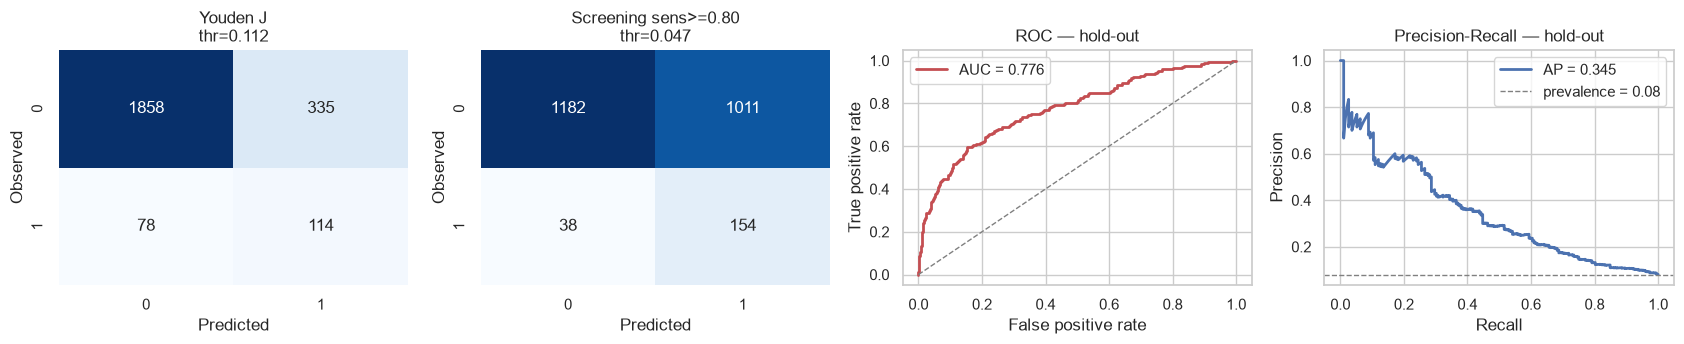

              precision    recall  f1-score   support

 No dementia       0.96      0.85      0.90      2193
    Dementia       0.25      0.59      0.36       192

    accuracy                           0.83      2385
   macro avg       0.61      0.72      0.63      2385
weighted avg       0.90      0.83      0.86      2385



In [7]:
# --- Step 3: single final fit on the full training partition, one pass at hold-out -----
final_model = make_model(**best_params)
final_model.fit(X_train_m, y_train, **FIT_KWARGS)
proba_raw = final_model.predict_proba(X_test_m)[:, 1]

auc = roc_auc_score(y_test, proba_raw)
pr_auc = average_precision_score(y_test, proba_raw)
brier_raw = brier_score_loss(y_test, proba_raw)
thr_youden, thr_screen, points = operating_points(y_test, proba_raw)

pts = pd.DataFrame(points).T.round(3)
pts["threshold"] = [thr_youden, thr_screen]
display(pts)
print(f"Hold-out ROC-AUC = {auc:.3f} (LR 0.771, delta {auc - LR_BASELINE['holdout_auc']:+.3f}) | "
      f"PR-AUC = {pr_auc:.3f} (LR 0.337) | Brier = {brier_raw:.3f} (LR 0.063)")

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (name, thr) in zip(axes[:2], [("Youden J", thr_youden),
                                      ("Screening sens>=0.80", thr_screen)]):
    cm = confusion_matrix(y_test, (proba_raw >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
    ax.set_title(f"{name}\nthr={thr:.3f}")
fpr, tpr, _ = roc_curve(y_test, proba_raw)
axes[2].plot(fpr, tpr, color="#c44e52", lw=2, label=f"AUC = {auc:.3f}")
axes[2].plot([0, 1], [0, 1], "--", c="grey", lw=1)
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC — hold-out"); axes[2].legend()
prec, rec, _ = precision_recall_curve(y_test, proba_raw)
axes[3].plot(rec, prec, color="#4c72b0", lw=2, label=f"AP = {pr_auc:.3f}")
axes[3].axhline(y_test.mean(), ls="--", c="grey", lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall — hold-out"); axes[3].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba_raw >= thr_youden).astype(int),
                            target_names=["No dementia", "Dementia"]))


E:\anaconda3\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


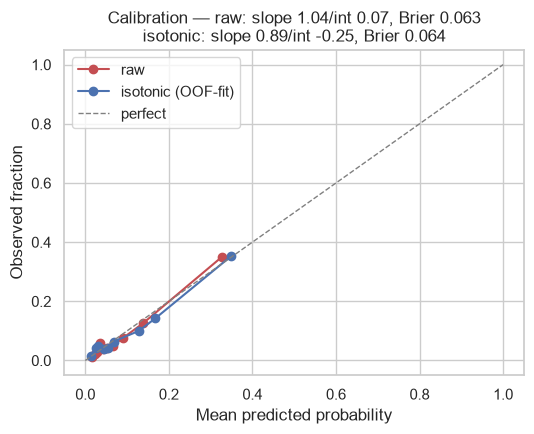

In [8]:
# --- Step 4: calibration — raw vs OOF-fitted isotonic ----------------------------------
# The isotonic mapping is fitted on TRAIN-only out-of-fold predictions, then applied to
# the hold-out. The hold-out is never used for its own recalibration.
oof = np.zeros(len(X_train_m))
for tr, va in CV5.split(X_train_m, y_train):
    m = make_model(**best_params)
    m.fit(X_train_m.iloc[tr], y_train.iloc[tr], **FIT_KWARGS)
    oof[va] = m.predict_proba(X_train_m.iloc[va])[:, 1]

from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds="clip").fit(oof, y_train)
proba_iso = iso.predict(proba_raw)

slope_raw, int_raw = calib_slope_intercept(y_test, proba_raw)
slope_iso, int_iso = calib_slope_intercept(y_test, proba_iso)
brier_iso = brier_score_loss(y_test, proba_iso)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for p, c, lbl in [(proba_raw, "#c44e52", "raw"), (proba_iso, "#4c72b0", "isotonic (OOF-fit)")]:
    frac, mean_p = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_p, frac, "o-", color=c, label=lbl)
ax.plot([0, 1], [0, 1], "--", c="grey", lw=1, label="perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraction")
ax.set_title(f"Calibration — raw: slope {slope_raw:.2f}/int {int_raw:.2f}, Brier {brier_raw:.3f}\n"
             f"isotonic: slope {slope_iso:.2f}/int {int_iso:.2f}, Brier {brier_iso:.3f}")
ax.legend()
plt.tight_layout(); plt.show()


In [9]:
# --- Step 5: subgroup performance (fairness drift check, modelx §8) --------------------
subgroups = []
for col, label in [("sex", "Sex"), ("residence", "Residence")]:
    for grp in X_test[col].dropna().unique():
        m = (X_test[col] == grp).values
        if m.sum() and y_test[m].sum() > 0:
            subgroups.append({
                "subgroup": f"{label}: {grp}", "n": int(m.sum()),
                "events": int(y_test[m].sum()),
                "ROC-AUC": roc_auc_score(y_test[m], proba_raw[m]),
                "mean_pred": proba_raw[m].mean(), "observed": y_test[m].mean(),
            })
sub_df = pd.DataFrame(subgroups)
display(sub_df.round(3))
print("Drift check: compare mean_pred vs observed (calibration) per row.")


,subgroup,n,events,ROC-AUC,mean_pred,observed
0,Sex: Male,1070,83,0.798,0.075,0.078
1,Sex: Female,1315,109,0.756,0.087,0.083
2,Residence: Rural,1579,134,0.763,0.085,0.085
3,Residence: Urban,806,58,0.802,0.076,0.072


Drift check: compare mean_pred vs observed (calibration) per row.


## 4 · Interpretation

,feature,importance,sd
0,age_years,0.1267,0.0138
1,hypertension_dx,0.0095,0.0040
2,hearing_difficulty,0.0058,0.0018
3,prior_stroke,0.0050,0.0025
4,lives_alone,0.0041,0.0021
5,vision_difficulty,0.0031,0.0024
6,gds15_score,0.0028,0.0019
7,education_years,0.0025,0.0016
8,family_history_dementia,0.0023,0.0021
9,diabetes_dx,0.0022,0.0014


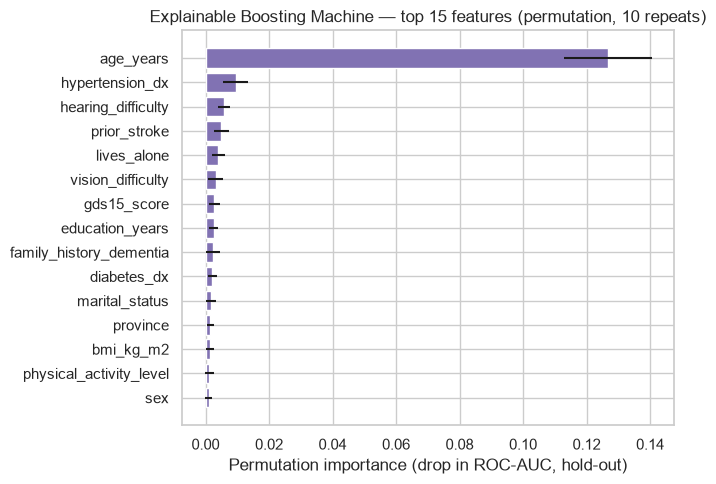

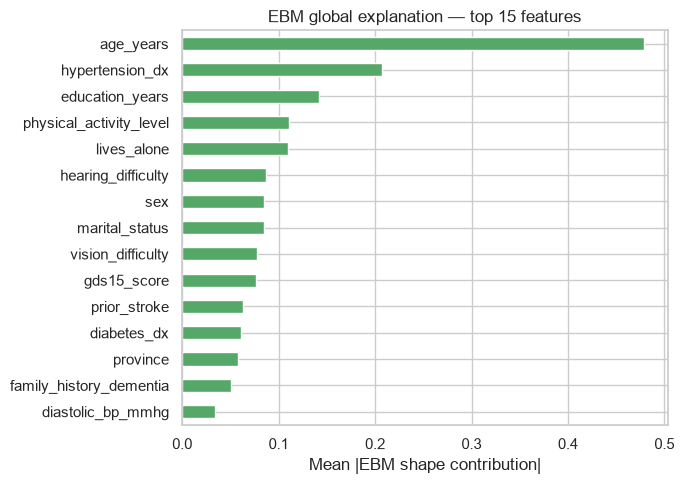

In [10]:
# --- Step 6: what drives the model — permutation importance (model-agnostic) ----------
perm = permutation_importance(final_model, X_test_m, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
perm_tab = (pd.DataFrame({"feature": X_test_m.columns,
                          "importance": perm.importances_mean,
                          "sd": perm.importances_std})
            .sort_values("importance", ascending=False).reset_index(drop=True))
display(perm_tab.head(15).round(4))

fig, ax = plt.subplots(figsize=(7, 5))
top = perm_tab.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance"], xerr=top["sd"], color="#8172b3")
ax.set_xlabel("Permutation importance (drop in ROC-AUC, hold-out)")
ax.set_title(f"{MODEL_NAME} — top 15 features (permutation, 10 repeats)")
plt.tight_layout(); plt.show()

# EBM's own global explanation: mean absolute shape-function contribution per feature.
try:
    glob = final_model.explain_global()
    names = list(glob.data()["names"])
    scores = glob.data()["scores"]
    imp = pd.Series([float(np.mean(np.abs(s))) for s in scores], index=names).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    imp.tail(15).plot.barh(color="#55a868", ax=ax)
    ax.set_xlabel("Mean |EBM shape contribution|")
    ax.set_title("EBM global explanation — top 15 features")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Native EBM importance extraction skipped:", e)



In [11]:
# --- Step 7: export artefacts for the cross-model comparison notebook ------------------
metrics = {
    "model": MODEL_NAME,
    "best_params": {k: (v.item() if hasattr(v, "item") else v) for k, v in best_params.items()},
    "cv_default": default_sum,
    "cv_tuned": tuned_sum,
    "holdout": {
        "roc_auc": float(auc), "pr_auc": float(pr_auc),
        "brier_raw": float(brier_raw), "brier_isotonic": float(brier_iso),
        "calib_slope_raw": slope_raw, "calib_intercept_raw": int_raw,
        "calib_slope_isotonic": slope_iso, "calib_intercept_isotonic": int_iso,
        "threshold_youden": float(thr_youden), "threshold_screen": float(thr_screen),
        "youden": {k: float(v) for k, v in points["Youden J"].items()},
        "screening": {k: float(v) for k, v in points["Screening (sens>=0.80)"].items()},
    },
    "subgroups": sub_df.round(4).to_dict(orient="records"),
    "perm_importance_top15": perm_tab.head(15).round(5).to_dict(orient="records"),
}
with open(BENCH / f"{SLUG}_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)

pd.DataFrame({"y_true": y_test.values, "proba_raw": proba_raw, "proba_isotonic": proba_iso,
              "sex": X_test["sex"].values, "residence": X_test["residence"].values}
             ).to_csv(BENCH / f"{SLUG}_holdout_predictions.csv", index=False)

print("=" * 88)
print(f"{MODEL_NAME} vs LR incumbent — hold-out (n=2,385, 192 events)")
print(f"  ROC-AUC  {auc:.3f}  vs 0.771   ({auc - 0.771:+.3f})")
print(f"  PR-AUC   {pr_auc:.3f}  vs 0.337   ({pr_auc - 0.337:+.3f})")
print(f"  Brier    {brier_raw:.3f}  vs 0.063   ({brier_raw - 0.063:+.3f})   "
      f"[isotonic: {brier_iso:.3f}]")
sc = points["Screening (sens>=0.80)"]
print(f"  Screening point (sens>=0.80): sens {sc['sensitivity']:.3f} | spec {sc['specificity']:.3f} "
      f"| NPV {sc['NPV']:.3f}   [LR: 0.802 / 0.511 / 0.967]")
print("=" * 88)


Explainable Boosting Machine vs LR incumbent — hold-out (n=2,385, 192 events)
  ROC-AUC  0.776  vs 0.771   (+0.005)
  PR-AUC   0.345  vs 0.337   (+0.008)
  Brier    0.063  vs 0.063   (+0.000)   [isotonic: 0.064]
  Screening point (sens>=0.80): sens 0.802 | spec 0.539 | NPV 0.969   [LR: 0.802 / 0.511 / 0.967]


## Takeaways

- **Discrimination**: does the tuned hold-out AUC beat 0.771 by a meaningful margin? Check `model_comparison.ipynb` for the paired DeLong test against the LR incumbent — a point estimate alone is not evidence.
- **Calibration**: trees rarely self-calibrate; the OOF isotonic variant is the deployable probability source if the raw curve bends.
- **Interpretability**: EBM is glass-box: exact per-feature shape functions + ranked pairwise interactions — the natural successor to the LR odds-ratio narrative.
- All artefacts: `outputs/benchmark/ebm_metrics.json`, `ebm_holdout_predictions.csv` — consumed by `model_comparison.ipynb`.
